# Localizing with TEM-t Over Fourier Codes

In [Localizing with TEM](localizing_with_tem.ipynb) we used a TEM model to localize a point using belief maps and convolutions. But the TEM paper, and the brain generally, uses Fourier location codes. 

## Fourier Location Encoding

Grid cells in $d$ dimensions (usually $d=2$) fire with a rate described by
$$
r_j(x) = \left(\sum_{i=1}^{d+1} A_{ij} \cos\left(\vphantom{x^x}k_{i}\cdot x + \phi_{ij}\right)\right)_+
$$
when the organism is at position $x$, where $A_{ij}$ is a fixed amplitude and $k_{i}$ is a wave vector, one of $d + 1$ unit vectors whose convex hull forms the simplex. In 2-D, these vectors start at the origin and are radially separated by $120^\circ$. In 3-D, four wavevectors are needed, pointing the the vertices of a triangular pyramid.

We can model these cells via an assemblage of column vectors having the form
$$
\eta_{ij}(x) = \left(\begin{array}{c}
    \cos (\alpha_j k_i\cdot x + \phi_j) \\
    \sin (\alpha_j k_i\cdot x + \phi_j)
\end{array}\right)
$$
where the $\{\phi_j\}$ are chosen to cover the interval $[0, 2\pi)$. Sufficiently wide choices of $\phi_j$ will cover the full circle.

Grid cell responses are periodic as the animal moves around its environment, and thanks to the identity
$$
\cos a \cos b  + \sin a \sin b = \cos (a - b) = \cos (b - a)
$$
we can arrive a relationship between displacement in physical space and rotation in Fourier space. To do this, we form a matrix $K$ whose rows range over $k_i$, so that $K$ is a $(d+1) \times d$ matrix. The rows of $K$ span $\mathbb{R}^d$, so the $d \times d$ matrix $K^TK$ is invertible, and the $d \times (d+1)$ pseudoinverse of this matrix is $K^\dagger = (K^TK)^{-1}K^T$ has $K^\dagger K = I$. Then we have
$$
\left(\vphantom{x^{x^x}}\eta_{ij}(x), \,\eta_{ij}(x + \Delta x)\right) \,\,=\,\, 
\cos(\alpha_j k_i\cdot \Delta x)
\quad\quad\text{whence}\quad\quad \exists n \in \mathbb{Z}^{d+1}\quad\text{s.t.}\quad\quad
\Delta x = \frac{2\pi n}{\alpha_j} + \alpha_j^{-1}K^\dagger \,\,\mathrm{arccos} \left(\vphantom{x^{x^x}}\rho_j(x, \Delta x)\right)
$$
where $\rho_j(x, \Delta_x)$ is the $(d+1)$-dimensional column vector whose entries are $\left(\rho_j(x, \Delta x)\right)_i \,=\, \eta_{ij}(x)^T\,\eta_{ij}(x + \Delta x)$. With sufficient and carefully chosen $(\alpha_j, \phi_j)$, these modular constants can be solved for a wide range of $n$, and $\Delta x$ can be identified exactly on this range.

The firing rates of an assemblage of grid cells with different phases $\phi_i$ can be stably and reliably inverted to retrieve the physical location $x$.

Without digressing further, we can use location codes of the form $\ell \in [-1, 1]^D$ to encode physical location, using dot products $(\ell, \ell')$ to express location affinity in a spatial memory as we have been doing with [real vectors](./map_testing.ipynb) or [location beliefs](./belief-maps.ipynb). The Fourier encoding, however, has the benefit of acting just like a normal transformer, since we can compute a location affinity by just taking dot products.

## Simultaneous Localization and Mapping (SLAM), Neural Style

It's all very nice that grid cells can move freely between a Fourier-like code and physical displacement, $\Delta x \leftrightarrow \Delta \theta$, but our problem is that we don't know _either_ the displacement or the location. All we have is sequences of sensory percepts $z = (z_1, \ldots, z_T)$ and actions $a = (a_1, \ldots, a_T)$. From this, we want to infer location and movement.

In robotics, this problem is known as SLAM, simultaneous localization and mapping. But there do not appear to be any true neural approaches to the problem. The difference here is that we are willing to accept an abstract, uninterpretable localization, provided that it is internally useful to the robot.

To express the problem, we want a function $f$ that maps sensory perception and actions to locations, $f(z, a) = \ell$. We'll do this for the whole time series all at once, because we need to be able to correct errors in past localization. However, we'll also constrain the problem so that the effect of actions on locations is predictable. To this end, we'll require that $\ell_{t+1} = h(\ell_t, a_t)$. We'll refine this more below.

This problem can be solved in a manner very similar to Whittington's [TEM-t](https://arxiv.org/abs/2112.04035). Mainly, we need a way to know when $\ell' = f(z, a)$ is wrong. We can check agreement with a second location estimate $\ell'$ driven by $h$ by progressively applying $\ell''_{t+1} = h(\ell_t, a_t)$, or even by applying $\ell''_{t+1} = h(\ell'_t, a_t)$. Then minimizing
$$
\mathcal{L}_{\text{action}} = -\frac{1}{T}\sum_t \|\ell'_t - \ell''_t\|^2
$$
will train $f$ to reflect the actions, but not the senses. But if we create a second function $g$ that maps locations to sensory percepts, $g(\ell') = z'$, then we can minimize the error in sensory prediction with loss
$$
\mathcal{L}_{\text{sensory}} = -\frac{1}{T}\sum_t s(z_t, z'_t)
\quad\quad\text{for}\quad\quad
s(z_t, z'_t) = (z_t, z'_t)
\quad\text{or}\quad
s(z_t, z'_t) = \| z_t - z'_t\|^2,
$$
depending on the geometry of the senses. If the $z$ are unit vectors, the two coincide modulo constant factors. We will use the squared norm, because our sensory percepts in tree world are not guaranteed to be unit vectors. But within transformer attention, we will use dot-product to compare sensory percepts.

Finally, we can train a model that attempts to fit both the actions and the sensory input using the combined loss
$$
\mathcal{L} = \mathcal{L}_{\text{sensory}} + \lambda\mathcal{L}_{\text{actions}}
$$
where $\lambda > 0$ is a tradeoff factor. This approach is essentially the same as the approach in TEM-t, which the authors describe as a VAE but then train with a deterministic loss the minimizes the sensory prediction error and the deviation of sensory-driven location predictions from action-driven location predictions under Gaussian assumptions. The main difference here is that whereas the TEM authors have only a few discrete actions and can thus model $\ell_t = W_a \ell_{t-1}$, we have continuous actions and must model $\ell_t = h(\ell_{t-1}, a_{t-1})$. 

In the spirit of TEM-t, we will use a transformer as our function $f$. It will begin with a current location estimate $\ell$ (initialized, say, to all zeros) and have 3 components:
- The *sensory predictor* $g$ such that $z' = g(\ell', z)$, which will be a transformer that matches the current location with previous locations and copies the old sensory information. A causal mask will prevent the current timestep from being used in prediction (we want the sensory predict based only on _prior_ timesteps), and the initial skip connection will be blocked so that the transformer cannot cheat by outputting zero from the attention component.
- The *location refiner* $f$ such that $\ell' = f(\ell, a)$ that will take the previous location estimates up to time $t$ and output a refined location estimate up to $t+1$. This will perform attention based on $z$, with $\ell$ as the value. Importantly, we will use the action-based location prediction $\ell''$ as a position encoding on $z$ so that if $z_t = z_{t'}$ for $t \neq t'$, there is a way to distinguish them based on $\ell''_t$ and $\ell''_{t'}$, unless the predicted locations are the same, in which case they should *not* be distinguished. Crucially, the matching of sensory percepts does *not* depend directly on $\ell$, and `stop_gradient` should be called on these position embeddings to prevent $h$ from being contaminated by the location refiner's errors.
- The *geometric predictor* $h$ calculates the expected location code updates given the actions. It uses the block-diagonal rotations described above to enforce fourier-space assumptions (more details below)

The following image lays this out graphically.

![Alt Architectural Details for Modified TEM-t](./mod_tem_t_detail.png "Architectural Details for Modified TEM-t")

The overall architecture of the components is shown below, including losses. As an augmentation, we consider the possibility of refining $\ell'$ for several steps by integrating geometric information, again with `stop_gradient` applied. Practically, this sort of iterative refinement will happen naturally by running the location prediction inside an agent's control logic.

![Alt text](./mod_tem_t_arch.png "Optional title")

## Transformer basics

So, let's add some transformer layers. It won't be self-attention, as we'll be choosing queries, keys, and values, so we do have to write a little code for this:

In [71]:
import torch


class TemTransformerFeedForward(torch.nn.Module):
    def __init__(self, embed_dim: int, hidden_dim: int, dropout: float=0.1):
        super().__init__()
        self.embed_dim = embed_dim
        self.hidden_dim = hidden_dim
        self.dropout = dropout

        self.fc1 = torch.nn.Linear(embed_dim, hidden_dim)
        self.fc1_dropout = torch.nn.Dropout(dropout)
        
        self.fc_silu = torch.nn.Linear(embed_dim, hidden_dim)

        self.fc2 = torch.nn.Linear(hidden_dim, embed_dim)
        self.fc2_dropout = torch.nn.Dropout(dropout)

    def forward(self, x: torch.Tensor):
        y = self.fc1(x)
        z = self.fc_silu(x)
        x = torch.nn.functional.silu(y) * z
        x = self.fc1_dropout(x)

        x = self.fc2(x)
        x = self.fc2_dropout(x)
        return x


class TemTransformerLayer(torch.nn.Module):
    def __init__(self, key_dim: int, value_dim: int, embed_dim: int, num_heads: int, dropout: float=0.1):
        super().__init__()
        self.key_dim = key_dim
        self.value_dim = value_dim
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.dropout = dropout

        self.q_proj = torch.nn.Linear(key_dim, embed_dim, bias=False)
        self.k_proj = torch.nn.Linear(key_dim, embed_dim, bias=False)
        self.v_proj = torch.nn.Linear(value_dim, embed_dim, bias=False)
        self.v_out = torch.nn.Linear(embed_dim, value_dim, bias=False)

        self.attention = torch.nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, bias=False, batch_first=True)
        self.attention_norm = torch.nn.LayerNorm(embed_dim)

        self.feed_forward = TemTransformerFeedForward(value_dim, 4*value_dim, dropout)
        self.feed_forward_norm = torch.nn.LayerNorm(value_dim)

    def forward(
        self, 
        query: torch.Tensor, 
        key: torch.Tensor, 
        value: torch.Tensor, 
        add_residual: bool=True, 
        allow_self_attention: bool=True,
        mask: torch.Tensor=None
    ):
        query = self.q_proj(query)
        key = self.k_proj(key)
        value_p = self.v_proj(value)

        value_p = self.attention_norm(value_p)

        if mask is None:
            if allow_self_attention:
                diagonal = 1
            else:
                diagonal = 0

            base = torch.full((query.shape[1], key.shape[1]), float('-inf'), dtype=query.dtype, device=query.device)
            mask = torch.triu(base, diagonal=diagonal)

        attn_output, attn_output_weights = self.attention(query, key, value_p, attn_mask=mask)

        if not allow_self_attention:
            attn_output[:, 0, :] = torch.zeros_like(attn_output[:, 0, :])

        attn_output = self.v_out(attn_output)

        if add_residual:
            x = value + self.feed_forward_norm(attn_output)
        else:
            x = self.feed_forward_norm(attn_output)

        y = self.feed_forward(x)
        return y + x


In [72]:
key_dim = 5
value_dim = 3
embed_dim = 16
num_heads = 4

transformer_layer = TemTransformerLayer(key_dim, value_dim, embed_dim, num_heads)

queries = torch.empty((2, 5, key_dim)).uniform_(-1, 1)
keys = torch.empty((2, 5, key_dim)).uniform_(-1, 1)
values = torch.empty((2, 5, value_dim)).uniform_(-1, 1)
z_full_attention = transformer_layer.forward(queries, keys, values, mask=torch.ones((5, 5)))

print(f"full attention z.shape: {z_full_attention.shape} max: {z_full_attention.max()} min: {z_full_attention.min()}")

z_auto_causal = transformer_layer.forward(queries, keys, values, mask=None)

print(f"causal z.shape: {z_auto_causal.shape} max: {z_auto_causal.max()} min: {z_auto_causal.min()}")

z_no_residual = transformer_layer.forward(queries, keys, values, add_residual=False)

print(f"no residual z.shape: {z_no_residual.shape} max: {z_no_residual.max()} min: {z_no_residual.min()}")

z_no_self_attention = transformer_layer.forward(queries, keys, values, allow_self_attention=False)

print(f"no self attention z.shape: {z_no_self_attention.shape} max: {z_no_self_attention.max()} min: {z_no_self_attention.min()}")

z_no_residual_no_self_attention = transformer_layer.forward(queries, keys, values, add_residual=False, allow_self_attention=False)

print(f"no residual no self attention z.shape: {z_no_residual_no_self_attention.shape} max: {z_no_residual_no_self_attention.max()} min: {z_no_residual_no_self_attention.min()}")

full attention z.shape: torch.Size([2, 5, 3]) max: 1.7394300699234009 min: -1.82443106174469
causal z.shape: torch.Size([2, 5, 3]) max: 2.005824565887451 min: -1.9608192443847656
no residual z.shape: torch.Size([2, 5, 3]) max: 1.307153344154358 min: -1.6297338008880615
no self attention z.shape: torch.Size([2, 5, 3]) max: 1.8412400484085083 min: -2.152343273162842
no residual no self attention z.shape: torch.Size([2, 5, 3]) max: 1.415123701095581 min: -1.4180465936660767


## Geometric Action Decoder

We need a function to update locations based on actions, $\ell_t = h(\ell_{t-1}, a_{t-1})$.

We will assume our actions $a_t$ has an impact on location as translation in physical space. If we assume Fourier location codes (like $\eta_{ij}$ above), then a displacement $\Delta x$ becomes a block-wise rotation of each $\eta_{ij}$. Recall that a rotation by angle $\theta$ is 
$$
R(\theta) = \left[\begin{array}{cc}
    \cos \theta & -\sin \theta \\
    \sin \theta & \cos \theta
\end{array}\right],
$$
so notating $\eta_{ij} = \left(\begin{array}{c}x\\y\end{array}\right)$, we have
$$
R(\theta_{ij})\eta_{ij} = \left(\begin{array}{c}
x\cos\theta_{ij} - y\sin\theta_{ij} \\
x\sin\theta_{ij} + y\cos\theta_{ij}
\end{array}\right).
$$

Beyond this rotational update, the Fourier coding can remain implicit in our location-learning scheme. Thus we do not need to know $\alpha_j$ or $\phi_{ij}$, but instead we allow $\theta_{ij}$ to differ for each $ij$. Then we can learn a function $g_\phi$ with parameters $\phi$ and apply it as a block-diagonal matrix multiply as follows:
$$
\theta_{ij} = g_\phi(a_{t-1})
\quad\quad\text{and}\quad\quad
\ell_t = \left[\begin{array}{ccc}
R(\theta_{00}) & \ldots & 0 \\
\vdots & \ddots & \vdots \\
0 & \ldots & R(\theta_{IJ})
\end{array}\right] \ell_{t-1}
$$
This treats $\ell_t$ as a sequence of pairs of components $\eta_{ij}$ under some enumeration of $ij$. The following code implements this scheme more efficiently, without assembling the full block-diagonal matrix. Each application extends the input sequence by one.

In [73]:
class GeometricActionDecoder(torch.nn.Module):
    def __init__(self, location_dim: int, action_dim: int, hidden_dim: int, dropout: float=0.25):
        super().__init__()
        self.location_dim = location_dim
        self.action_dim = action_dim
        self.hidden_dim = hidden_dim
        self.dropout = dropout
        assert location_dim % 2 == 0

        self.action_mlp = torch.nn.Sequential(
            torch.nn.Linear(action_dim, hidden_dim),
            torch.nn.LayerNorm(hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(hidden_dim, location_dim // 2),
        )

    def forward(self, location: torch.Tensor, action: torch.Tensor, eps: float=1e-6, allow_extension: bool=True):
        B, T, D = location.shape
        assert D == self.location_dim
        assert (B, T, self.action_dim) == action.shape

        # use a block diagonal matrix to rotate the location
        thetas = self.action_mlp(action)
        cos_thetas = torch.cos(thetas)
        sin_thetas = torch.sin(thetas)

        location_blocks = location.reshape(B, T, -1, 2)
        location_cos_thetas = location_blocks * cos_thetas[..., None]
        location_sin_thetas = location_blocks * sin_thetas[..., None]

        next_location = torch.stack([
            location_cos_thetas[..., 0] - location_sin_thetas[..., 1],
            location_sin_thetas[..., 0] + location_cos_thetas[..., 1],
        ], dim=-1).reshape(B, T, D)

        # shift the location one step forward to align with the past; output is one step longer than the input
        next_location = torch.cat([location[:, :1], next_location], dim=1)

        if allow_extension:
            return next_location
        else:
            return next_location[:, :-1]


In [85]:
action_dim = 2
location_dim = 4
actions = torch.empty((2, 5, action_dim)).uniform_(-1, 1)
location = torch.empty((2, 5, location_dim)).uniform_(-1, 1)

geometric_action_decoder = GeometricActionDecoder(location_dim, action_dim, 16)

geometric_location =geometric_action_decoder(location, actions)
print("before: ", location.shape)
print(location)
print("after: ",geometric_location.shape)
print(geometric_location)

before:  torch.Size([2, 5, 4])
tensor([[[ 0.1510, -0.1195, -0.8468, -0.9996],
         [-0.5908,  0.6325,  0.0132,  0.0185],
         [-0.5650,  0.3664,  0.9749, -0.3979],
         [-0.8162,  0.9914, -0.9074, -0.1432],
         [-0.4937,  0.7634, -0.1818,  0.0444]],

        [[-0.4086, -0.6407,  0.2067,  0.8112],
         [ 0.7804,  0.9311, -0.1486, -0.1408],
         [-0.9089, -0.9228, -0.3895, -0.5645],
         [-0.3927, -0.3897, -0.7525,  0.2587],
         [-0.1115, -0.3103,  0.8361, -0.5005]]])
after:  torch.Size([2, 6, 4])
tensor([[[ 0.1510, -0.1195, -0.8468, -0.9996],
         [ 0.1734,  0.0837, -0.2571, -1.2846],
         [-0.7745,  0.3863,  0.0171,  0.0149],
         [-0.6552, -0.1554,  1.0515, -0.0568],
         [-1.0915, -0.6765, -0.8573, -0.3301],
         [-0.9063,  0.0712, -0.1866,  0.0150]],

        [[-0.4086, -0.6407,  0.2067,  0.8112],
         [ 0.4731, -0.5946,  0.0763,  0.8336],
         [ 0.0353,  1.2143, -0.1662, -0.1196],
         [ 0.5031, -1.1936, -0.6346, -0.

## Putting it Together

Now that we have the basic transformer layers and a geometric decoder, we can assemble the full model.

In [152]:
from typing import Optional

class TemLocalizer(torch.nn.Module):
    def __init__(self, location_dim: int, sensory_dim: int, action_dim: int, embed_dim: int, num_heads: int=8, action_hidden_dim: int=128, dropout: float=0.1):
        super().__init__()
        self.location_dim = location_dim
        self.sensory_dim = sensory_dim
        self.action_dim = action_dim
        self.embed_dim = embed_dim
        self.dropout = dropout

        self.location_refiner = TemTransformerLayer(sensory_dim, location_dim, embed_dim, num_heads, dropout)
        self.sensory_predictor = TemTransformerLayer(location_dim, sensory_dim, embed_dim, num_heads, dropout)

        self.geometric_action_decoder = GeometricActionDecoder(location_dim, action_dim, action_hidden_dim, dropout)

        self.position_encoder = torch.nn.Linear(location_dim, sensory_dim)

    def forward(self, sensory: torch.Tensor, prior_location: Optional[torch.Tensor]=None, action: Optional[torch.Tensor]=None, 
                max_steps: int=4, threshold: float=0.05, refine_alpha: float=0.1, eps: float=1e-6):
        assert max_steps > 0

        B, T, S = sensory.shape
        if prior_location is None:
            initial_location = torch.zeros((B, 1, self.location_dim), dtype=sensory.dtype, device=sensory.device)
            return initial_location, initial_location, torch.zeros_like(sensory), 0.0, 0.0
        
        # These next two ifs let us just supply the previous output location and action sequence, and extend them to the new length
        if prior_location.shape[1] < T:
            prior_location = torch.cat([
                prior_location, 
                torch.zeros((B, T - prior_location.shape[1], self.location_dim), 
                dtype=prior_location.dtype, 
                device=prior_location.device
            )], dim=1)
        
        if action.shape[1] < T:
            action = torch.cat([
                action, 
                torch.zeros((B, T - action.shape[1], self.action_dim), 
                dtype=action.dtype, 
                device=action.device
            )], dim=1)

        sensory_location = prior_location
        geometric_location = self.geometric_action_decoder(prior_location, action, allow_extension=False) # <-- we've already extended the action sequence
        sensory_plus_geometric = sensory + self.position_encoder(geometric_location.detach()) # <-- stop_gradient     
        
        for _ in range(max_steps):
            sensory_location = self.location_refiner(sensory_plus_geometric, sensory_plus_geometric, sensory_location)
            location_disagreement = (geometric_location - sensory_location).pow(2).sum(dim=-1)
            if (location_disagreement < threshold).all():
                break

            sensory_location = (1 - refine_alpha) * sensory_location + refine_alpha * geometric_location.detach()

        sensory_predicted = self.sensory_predictor(
            sensory_location, sensory_location, sensory, allow_self_attention=False, add_residual=False
        )
        sensory_error = (sensory - sensory_predicted).pow(2).sum(dim=-1)  # <-- or, if we want to use a norm comparison

        return geometric_location, sensory_location, sensory_predicted, sensory_error.mean(), location_disagreement.mean()

    @classmethod
    def from_config(cls, config: 'TreeWorldConfig'):
        return cls(
            location_dim=config.location_dim,
            sensory_dim=config.sensory_embedding_dim,
            action_dim=config.dim,
            embed_dim=config.embed_dim,
            num_heads=config.num_heads,
            action_hidden_dim=config.action_hidden_dim,
            dropout=config.dropout,
        )


In [153]:
sensory_dim = value_dim
localizer = TemLocalizer(location_dim, sensory_dim, action_dim, embed_dim, num_heads, action_hidden_dim=16, dropout=0.1)

B = 2
T = 5
sensory = torch.empty((B, T, value_dim)).normal_()
prior_location = torch.empty((B, T-1, location_dim)).uniform_(-1, 1)
action = torch.empty((B, T-1, action_dim)).normal_()

next_location, sensory_location, sensory_predicted, sensory_error, location_disagreement = localizer(sensory, prior_location, action)

print(f"location shape change: {prior_location.shape} -> {next_location.shape}")
print(f"sensory shape: {sensory.shape} -> {sensory_predicted.shape}")
print(f"sensory error: {sensory_error}")
print(f"location disagreement: {location_disagreement}")

location shape change: torch.Size([2, 4, 4]) -> torch.Size([2, 5, 4])
sensory shape: torch.Size([2, 5, 3]) -> torch.Size([2, 5, 3])
sensory error: 5.589928150177002
location disagreement: 140.02967834472656


## Experimenting in Tree World



In [ ]:
import math

from tree_world.simulation import AgentModel
from typing import Optional


class PathTracingTemTAgent(AgentModel):
    def __init__(
        self, 
        tem_model: TemLocalizer=None,
        time_to_rotate_spiral: int=100,
        time_to_rotate_heading: int=25,
        distance_increment_first_spiral: float=25,
        action_noise: Optional[float]=None,
        lmbda: float=1.0
    ):
        self.t = 0

        self.alpha = distance_increment_first_spiral / time_to_rotate_spiral
        self.beta = 2 * math.pi / time_to_rotate_spiral
        self.gamma = 2 * math.pi / time_to_rotate_heading

        self.sign = 1.0

        self.tem = tem_model
        self.last_location = None
        self.last_action = None
        self.last_sensory = None

        self.location_history = []
        self.actual_location_history = []

        self.loss = []

        self.action_noise = action_noise
        self.action_norm = 0.0

        self.optimizer = torch.optim.AdamW(self.tem.parameters(), lr=1e-3)
        self.lmbda = lmbda

    def reset(self):
        self.t = 0
        self.location_history = []
        self.actual_location_history = []
        self.loss = []

        self.last_location = None
        self.last_action = None
        self.last_sensory = None
        
    def coords(self, t):
        r = self.alpha * t
        th = self.beta * t

        return torch.tensor([r * math.cos(th), r * math.sin(th)])

    def get_action(self, distance: float, embedding: torch.Tensor, heading: torch.Tensor, health: float,
                   agent_location: torch.Tensor=None, obj_location: torch.Tensor=None, reward: float=0.0):

        if self.last_action is not None:
            last_action = torch.stack(self.last_action, dim=1).requires_grad_()
            if self.action_noise is not None:
                last_action = last_action + torch.randn_like(self.last_action) * self.action_noise
        else:
            last_action = None

        if self.last_sensory is not None:
            self.last_sensory = torch.cat([
                    torch.tensor(self.last_sensory),
                    embedding[None, None, :]
            ], dim=1).requires_grad_()
        else:
            self.last_sensory = embedding[None, None, :].requires_grad_()

        next_location, sensory_location, sensory_predicted, sensory_error, location_disagreement = (
            self.tem(self.last_sensory, self.last_location, last_action)
        )
        
        # location_belief, loss = self.tem(self.last_location, self.last_action, embedding[None, :])
        self.last_location = next_location.detach().requires_grad_()
        self.location_history.append(sensory_location.detach())
        self.actual_location_history.append(agent_location)
        self.loss.append(sensory_error + self.lmbda * location_disagreement)

        ph = self.gamma * self.t

        start_coords = self.coords(self.t)
        end_coords = self.coords(self.t + 1)
        position_delta = end_coords - start_coords

        new_heading = torch.tensor([math.cos(ph), math.sin(ph)])
        if self.last_action is None:
            self.last_action = [position_delta.clone()[None, :]]
        else:
            self.last_action.append(position_delta.clone()[None, :])

        self.t = self.t + 1
        self.action_norm = torch.norm(position_delta) * (1 / self.t) + self.action_norm * (self.t - 1) / self.t

        return position_delta, new_heading

    def train(self):
        print(f"Taking an optimizer step with {len(self.loss)} loss values: {sum(self.loss)}")
        self.optimizer.zero_grad()
        sum(self.loss).backward()
        self.optimizer.step()
        self.loss = []
    
    @classmethod
    def from_config(cls, config: 'TreeWorldConfig'):
        tem_model = TemLocalizer.from_config(config)
        return cls(tem_model, action_noise=config.action_noise)

In [194]:
from tree_world.simulation import TreeWorldConfig, TreeWorld

config = TreeWorldConfig()

config.location_dim = 128
config.action_hidden_dim = 128
config.action_noise = None

config.model_type = "PathTracingTemTAgent"

world = TreeWorld.random_from_config(config)

Let's train the model with 25 runs, then record and look at the results.

In [ ]:
for i in range(25):
    world.randomize()
    world.run(1000, allow_death=False)

/var/folders/gw/zsqsy8v12h1fsqw6ph5ndprc0000gn/T/ipykernel_49819/3999389857.py:69: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.last_sensory),


Taking an optimizer step with 101 loss values
Taking an optimizer step with 100 loss values
Taking an optimizer step with 100 loss values
Taking an optimizer step with 100 loss values
Taking an optimizer step with 100 loss values
Taking an optimizer step with 100 loss values
Taking an optimizer step with 100 loss values
Taking an optimizer step with 100 loss values
Taking an optimizer step with 100 loss values
Taking an optimizer step with 101 loss values
Taking an optimizer step with 100 loss values
Taking an optimizer step with 100 loss values
Taking an optimizer step with 100 loss values
Taking an optimizer step with 100 loss values
Taking an optimizer step with 100 loss values
Taking an optimizer step with 100 loss values
Taking an optimizer step with 100 loss values
Taking an optimizer step with 100 loss values
Taking an optimizer step with 101 loss values
Taking an optimizer step with 100 loss values
Taking an optimizer step with 100 loss values
Taking an optimizer step with 100 

In [195]:
steps = 1000

print(f"Running tree world for {steps} steps...")
world.run(steps, record=True, allow_death=False)
print()
print("Tree world run complete.")

print(f"Agent health: {world.agent.health}")
print(f"Agent fruit eaten: {world.agent.fruit_eaten}")
print(f"Agent poisonous fruit eaten: {world.agent.poisonous_fruit_eaten}")
print(f"Agent total movement: {world.agent.total_movement}")
print(f"Agent final location: {torch.norm(world.agent.location).item()}")

Running tree world for 1000 steps...


/var/folders/gw/zsqsy8v12h1fsqw6ph5ndprc0000gn/T/ipykernel_49819/3999389857.py:69: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(self.last_sensory),


Taking an optimizer step with 101 loss values
Taking an optimizer step with 100 loss values
Taking an optimizer step with 100 loss values
Taking an optimizer step with 100 loss values
Taking an optimizer step with 100 loss values
Taking an optimizer step with 100 loss values
Taking an optimizer step with 100 loss values
Taking an optimizer step with 100 loss values
Taking an optimizer step with 100 loss values

Tree world run complete.
Agent health: -647.6583251953125
Agent fruit eaten: 19
Agent poisonous fruit eaten: 11
Agent total movement: 7863.29345703125
Agent final location: 53.0443229675293


/Users/alockett/dev/tree-world/src/tree_world/visualize.py:226: UserWarning: Glyph 108 (l) missing from font(s) Noto Emoji.
  fig.savefig(save_path, bbox_inches="tight", dpi=150)
/Users/alockett/dev/tree-world/src/tree_world/visualize.py:226: UserWarning: Glyph 112 (p) missing from font(s) Noto Emoji.
  fig.savefig(save_path, bbox_inches="tight", dpi=150)


(<Figure size 800x800 with 2 Axes>, <Axes: title={'center': 'TreeWorld run'}>)

/Users/alockett/dev/tree-world/venv/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 108 (l) missing from font(s) Noto Emoji.
  func(*args, **kwargs)
/Users/alockett/dev/tree-world/venv/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 112 (p) missing from font(s) Noto Emoji.
  func(*args, **kwargs)
/Users/alockett/dev/tree-world/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 108 (l) missing from font(s) Noto Emoji.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/alockett/dev/tree-world/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 112 (p) missing from font(s) Noto Emoji.
  fig.canvas.print_figure(bytes_io, **kw)


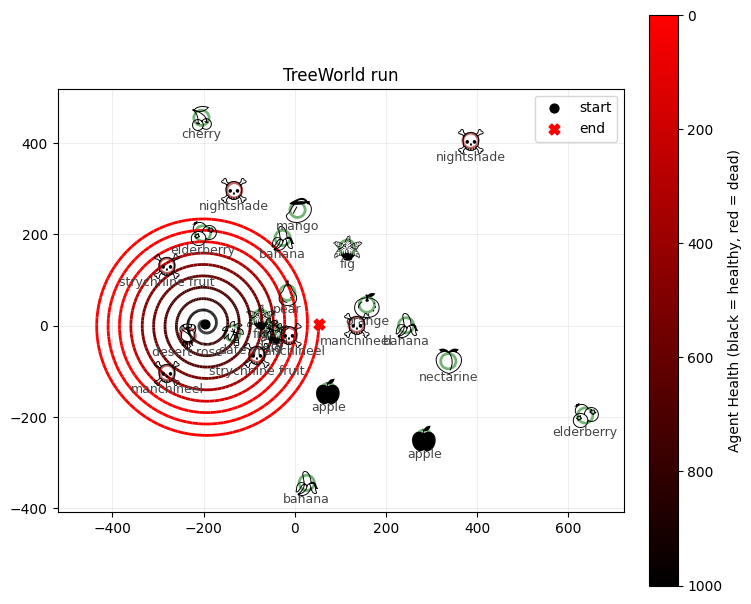

In [196]:
from tree_world.visualize import visualize_treeworld_run
visualize_treeworld_run(
    world.tree_locations.numpy().tolist(),
    [tree.name for tree in world.trees],
    [tree.is_poisonous for tree in world.trees],
    world.record_positions,
    world.record_healths,
    world.config.max_health,
    title="TreeWorld run",
    save_path="tree_world_run.png",
    show=False,
)

In [202]:
agent_location_history = torch.stack(world.agent.model.actual_location_history, dim=0)
geo_location_predictions = world.agent.model.last_location[0]
sense_location_predictions = world.agent.model.location_history[-1][0]

print(f"Agent location history: {agent_location_history.shape}")
print(f"Geometric location predictions: {geo_location_predictions.shape}")
print(f"Sense location predictions: {sense_location_predictions.shape}")

Agent location history: torch.Size([1000, 2])
Geometric location predictions: torch.Size([1000, 128])
Sense location predictions: torch.Size([1000, 128])


Now that we have a model, let's try to see if we can decode the locations meaningfully. We'll try two different things:
1. Train an MLP to predict $\alpha_j$ and $\phi_{ij}$ for an explicit grid model, using known agent locations.
2. Train an MLP to predict the agent locations directly and vice versa, checking to see if there is a bidirectional interpretation

In [ ]:
import sys

class MLP(torch.nn.Module):
    def __init__(self, input_dim: int, output_dim: int, hidden_dim: int=128):
        super().__init__()
        self.mlp = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_dim, output_dim),
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.mlp(x)


def fit_mlp(mlp: torch.nn.Module, input_tensor: torch.Tensor, output_tensor: torch.Tensor, steps: int=1000):
    optimizer = torch.optim.AdamW(mlp.parameters(), lr=1e-3)
    for i in range(steps):
        optimizer.zero_grad()
        output = mlp(input_tensor)
        loss = torch.nn.functional.mse_loss(output, output_tensor)
        loss.backward()
        optimizer.step()
        if i % 100 == 0:
            print(f"Step {i} loss: {loss.item()}", end="\r")
            sys.stdout.flush()
    
    print(f"Final loss: {loss.item()}")

def fit_indirect_model(agent_location_history: torch.Tensor, location_predictions: torch.Tensor):
    B, D = location_predictions.shape
    _, d = agent_location_history.shape
    # Fit an MLP to predict $\alpha_j$ and $\phi_{ij}$ for an explicit grid model, using known agent locations.
    loc_to_grid_mlp = MLP(2, D)
    print("Fitting location code --> explicit location with indirect model")
    fit_mlp(loc_to_grid_mlp, agent_location_history, location_predictions)

    grid_to_loc_mlp = MLP(D, 2)
    print("Fitting explicit location --> location code with indirect model")
    fit_mlp(grid_to_loc_mlp, location_predictions, agent_location_history)

    return loc_to_grid_mlp, grid_to_loc_mlp


print("Checking indirect fit with geometric location predictions")
loc_to_grid_mlp, grid_to_loc_mlp = fit_indirect_model(agent_location_history, geo_location_predictions)

print("Checking indirect fit with sense location predictions")
loc_to_grid_mlp, grid_to_loc_mlp = fit_indirect_model(agent_location_history, sense_location_predictions)


In [ ]:
class GridMLP2d(MLP):
    def __init__(self, location_dim: int, hidden_dim: int=128):
        super().__init__(2, location_dim, hidden_dim)
        self.ks = torch.tensor([
            [0, 1],
            [math.sqrt(3)/2, -0.5],
            [-math.sqrt(3)/2, -0.5],
        ])
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        y = self.mlp(x)
        alpha, phi = y.chunk(2, dim=-1)

        kx = torch.matmul(x, self.ks.T)
        eta_cos = torch.cos(alpha * kx + phi)
        eta_sin = torch.sin(alpha * kx + phi)

        return torch.stack([eta_cos, eta_sin], dim=-1).view_as(y)


def fit_grid_model(agent_location_history: torch.Tensor, location_predictions: torch.Tensor):
    grid_mlp = GridMLP2d(2)
    fit_mlp(grid_mlp, agent_location_history, location_predictions)

    return grid_mlp


print("Fitting grid model with geometric location predictions")
grid_mlp = fit_grid_model(agent_location_history, geo_location_predictions)

print("Fitting grid model with sense location predictions")
grid_mlp = fit_grid_model(agent_location_history, sense_location_predictions)


